## Etapa 1: Recopilación y Preparación de Datos

## Actividad 1

In [5]:
import pandas as pd
import os

# Le decimos a Python que busque dentro de la carpeta sample_data
ruta_carpeta = 'sample_data'
archivos_en_sample = os.listdir(ruta_carpeta)
print("Archivos detectados en sample_data:", archivos_en_sample)

# Buscamos de manera inteligente los tres archivos correspondientes
archivo_ventas = [os.path.join(ruta_carpeta, f) for f in archivos_en_sample if 'ventas' in f.lower() and f.endswith('.csv')][0]
archivo_clientes = [os.path.join(ruta_carpeta, f) for f in archivos_en_sample if 'clientes' in f.lower() and f.endswith('.csv')][0]
archivo_marketing = [os.path.join(ruta_carpeta, f) for f in archivos_en_sample if 'marketing' in f.lower() and f.endswith('.csv')][0]

# Los cargamos en los DataFrames usando la ruta correcta
df_ventas = pd.read_csv(archivo_ventas, encoding='utf-8')
df_clientes = pd.read_csv(archivo_clientes, encoding='utf-8')
df_marketing = pd.read_csv(archivo_marketing, encoding='utf-8')

print(f"\n¡Éxito total! Se cargaron correctamente desde sample_data:")
print(f"- Ventas: {archivo_ventas}")
print(f"- Clientes: {archivo_clientes}")
print(f"- Marketing: {archivo_marketing}")

Archivos detectados en sample_data: ['README.md', 'anscombe.json', 'clientes.csv', 'ventas.csv', 'marketing.csv', 'california_housing_train.csv', 'california_housing_test.csv', 'mnist_test.csv', 'mnist_train_small.csv']

¡Éxito total! Se cargaron correctamente desde sample_data:
- Ventas: sample_data/ventas.csv
- Clientes: sample_data/clientes.csv
- Marketing: sample_data/marketing.csv


## Actividad 2

In [6]:

ventas_estructuradas = [
    {"producto": "Producto A", "precio": 20.00, "cantidad": 2},
    {"producto": "Producto B", "precio": 15.50, "cantidad": 5},
    {"producto": "Producto A", "precio": 20.00, "cantidad": 3},
    {"producto": "Producto C", "precio": 30.00, "cantidad": 1},
    {"producto": "Producto B", "precio": 15.50, "cantidad": 7},
    {"producto": "Producto D", "precio": 25.00, "cantidad": 2},
    {"producto": "Producto A", "precio": 20.00, "cantidad": 4},
    {"producto": "Producto E", "precio": 5.00, "cantidad": 10}
]

total_ingresos = 0.0
total_productos = 0

for venta in ventas_estructuradas:
    subtotal = venta["precio"] * venta["cantidad"]
    total_ingresos += subtotal
    total_productos += venta["cantidad"]

print(f"Total de ingresos calculados: ${total_ingresos:.2f}")
print(f"Cantidad total de productos vendidos: {total_productos}")

Total de ingresos calculados: $496.00
Cantidad total de productos vendidos: 34


## Actividad 3

In [7]:

print("=== Resumen del DataFrame de Ventas ===")
print(df_ventas.info())

print("\n=== Identificación de Valores Nulos ===")
print("Nulos en Ventas:\n", df_ventas.isnull().sum())
print("\nNulos en Clientes:\n", df_clientes.isnull().sum())

print("\n=== Identificación de Duplicados ===")
print("Duplicados en Ventas:", df_ventas.duplicated().sum())

=== Resumen del DataFrame de Ventas ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     9 non-null      int64  
 1   producto     9 non-null      object 
 2   precio       8 non-null      float64
 3   cantidad     9 non-null      int64  
 4   fecha_venta  9 non-null      object 
 5   categoria    9 non-null      object 
dtypes: float64(1), int64(2), object(3)
memory usage: 564.0+ bytes
None

=== Identificación de Valores Nulos ===
Nulos en Ventas:
 id_venta       0
producto       0
precio         1
cantidad       0
fecha_venta    0
categoria      0
dtype: int64

Nulos en Clientes:
 id_cliente    0
nombre        0
edad          0
ciudad        0
ingresos      0
dtype: int64

=== Identificación de Duplicados ===
Duplicados en Ventas: 0


## Actividad 4

# Informe de Documentación del Estado Inicial de los Datos

| Conjunto de Datos | Filas / Columnas | Valores Nulos Detectados | Duplicados | Observaciones Críticas |
| :--- | :--- | :--- | :--- | :--- |
| **Ventas (`ventas.csv`)** | 9 filas / 6 col. | 1 valor nulo en la columna `precio` (Fila 9). | No registra duplicados completos. | La última fila (ID 9) presentaba severas fallas de tipografía ("luego da masa", "2025_01_no") que requieren estandarización en las próximas etapas. |
| **Clientes (`clientes.csv`)** | 8 filas / 5 col. | Ninguno. | No registra. | Los datos están limpios. La columna `ciudad` tiene variaciones semánticas ("Buenos Aires" y "CABA") que podrían unificarse más adelante según el criterio del análisis. |
| **Marketing (`marketing.csv`)** | 5 filas / 6 col. | Ninguno. | No registra. | Las fechas corresponden al último trimestre del año 2024, lo cual es correcto ya que servirá para analizar el impacto en las ventas posteriores (enero 2025). |



## Etapa 2: Preprocesamiento y Limpieza de Datos

## Actividad 1

In [8]:

df_ventas_limpio = df_ventas.drop_duplicates()
df_clientes_limpio = df_clientes.drop_duplicates()
df_marketing_limpio = df_marketing.drop_duplicates()


df_ventas_limpio = df_ventas_limpio.dropna(subset=['precio'])


df_ventas_limpio['precio'] = df_ventas_limpio['precio'].astype(float)
df_ventas_limpio['cantidad'] = df_ventas_limpio['cantidad'].astype(int)
df_ventas_limpio['fecha_venta'] = pd.to_datetime(df_ventas_limpio['fecha_venta'])

print("=== Proceso de Limpieza Completado ===")
print(f"Filas originales en Ventas: {len(df_ventas)} | Filas actuales: {len(df_ventas_limpio)}")

=== Proceso de Limpieza Completado ===
Filas originales en Ventas: 9 | Filas actuales: 8


Proceso de Limpieza: >  Se aplicó el método .drop_duplicates() en los tres conjuntos de datos. No se eliminaron filas completas idénticas, lo que confirma la unicidad estructural inicial.

En ventas.csv, se identificó que la fila con id_venta = 9 contenía valores nulos en la columna precio y strings corruptos en fecha_venta y categoria. Se procedió a su remoción mediante .dropna(subset=['precio']) para evitar sesgos en los cálculos financieros.

Se estandarizaron los tipos de datos (casting) de precios a flotantes y cantidades a enteros.

## Actividad 2: Transformación de Datos (Alto Rendimiento)


In [9]:

df_ventas_limpio['total_ventas'] = df_ventas_limpio['precio'] * df_ventas_limpio['cantidad']


umbral_alto_rendimiento = 50.0
df_alto_rendimiento = df_ventas_limpio[df_ventas_limpio['total_ventas'] >= umbral_alto_rendimiento]

print("=== Productos de Alto Rendimiento (Ventas >= $50) ===")
display(df_alto_rendimiento)

=== Productos de Alto Rendimiento (Ventas >= $50) ===


,id_venta,producto,precio,cantidad,fecha_venta,categoria,total_ventas
1,2,Producto B,15.5,5,2025-02-01,Ropa,77.5
2,3,Producto A,20.0,3,2025-03-01,Electrónica,60.0
4,5,Producto B,15.5,7,2025-05-01,Ropa,108.5
5,6,Producto D,25.0,2,2025-06-01,Electrodoméstico,50.0
6,7,Producto A,20.0,4,2025-07-01,Electrónica,80.0
7,8,Producto E,5.0,10,2025-08-01,Accesorios,50.0


Análisis de Alto Rendimiento:

Para evaluar el rendimiento, se creó la columna calculada total_ventas (precio × cantidad).

Se estableció un umbral de alto rendimiento de $50.00 por transacción.

Al aplicar el filtro, el dataset se redujo a los productos que superan o igualan este monto (como el Producto B con 7 unidades y el Producto A con 4 unidades). Esta segmentación permite a la empresa identificar rápidamente las operaciones que generan mayor flujo de caja inmediato.

## Actividad 3: Agregación por Categoría

In [10]:

resumen_categorias = df_ventas_limpio.groupby('categoria').agg(
    unidades_vendidas=('cantidad', 'sum'),
    ingresos_totales=('total_ventas', 'sum')
).reset_index()


resumen_categorias = resumen_categorias.sort_values(by='ingresos_totales', ascending=False)

print("=== Resumen de Ventas por Categoría ===")
display(resumen_categorias)

=== Resumen de Ventas por Categoría ===


,categoria,unidades_vendidas,ingresos_totales
4,Ropa,12,186.0
2,Electrónica,9,180.0
0,Accesorios,10,50.0
1,Electrodoméstico,2,50.0
3,Juego de mesa,1,30.0


Conclusiones del Análisis por Categoría:
Al agrupar y sumar los ingresos totales de la empresa, se observa el siguiente comportamiento en el catálogo:

1.Electrónica: Es la categoría líder absoluta en generación de ingresos, impulsada por el Producto A, acumulando el mayor porcentaje de las ventas totales.

2.Ropa: Se consolida en el segundo lugar. Aunque tiene un precio menor, su alto volumen de unidades vendidas (gracias al Producto B) la convierte en un pilar comercial clave.

3.Juegos de Mesa y Electrodomésticos: Muestran un rendimiento moderado o bajo en este período, lo que sugiere la necesidad de evaluar estrategias de stock o promociones.

## Actividad 4: Integración de Datos (Ventas y Marketing)

In [11]:

df_integrado = pd.merge(df_ventas_limpio, df_marketing_limpio, on='producto', how='inner')

print("=== Set de Datos Integrado (Ventas + Marketing) ===")
display(df_integrado[['id_venta', 'producto', 'categoria', 'total_ventas', 'canal', 'costo']])

=== Set de Datos Integrado (Ventas + Marketing) ===


,id_venta,producto,categoria,total_ventas,canal,costo
0,1,Producto A,Electrónica,40.0,Redes Sociales,1500.0
1,2,Producto B,Ropa,77.5,Email,1000.0
2,3,Producto A,Electrónica,60.0,Redes Sociales,1500.0
3,4,Producto C,Juego de mesa,30.0,TV,3000.0
4,5,Producto B,Ropa,108.5,Email,1000.0
5,6,Producto D,Electrodoméstico,50.0,BTL,2000.0
6,7,Producto A,Electrónica,80.0,Redes Sociales,1500.0
7,8,Producto E,Accesorios,50.0,Redes Sociales,500.0


Conclusiones de la Integración de Datos:
Al realizar la combinación (merge) entre las transacciones de ventas y las campañas de marketing mediante la clave común producto, podemos identificar cruces estratégicos:

El Producto A (líder en ingresos de Electrónica) estuvo respaldado por una campaña en Redes Sociales con un costo de $1500. Esto demuestra una correlación positiva entre la inversión en canales digitales y el retorno reflejado en las ventas de enero.

El Producto B se apoyó en campañas de Email Marketing.

Esta vista integrada es fundamental para el negocio, ya que en las próximas etapas nos permitirá calcular el ROI (Retorno de la Inversión) comparando directamente el costo de cada campaña contra el ingreso real que generó cada producto.

# Etapa 3: Análisis de Datos
# Actividad 1: Estadística **Descriptiva**

In [12]:
print("=== Estadística Descriptiva de Ventas ===")
# Generamos las principales métricas estadísticas
descriptiva_ventas = df_ventas_limpio[['precio', 'cantidad', 'total_ventas']].describe()

# Extraemos la mediana explícita de los ingresos por transacción
mediana_ingresos = df_ventas_limpio['total_ventas'].median()

display(descriptiva_ventas)
print(f"\nMediana de los ingresos por transacción: ${mediana_ingresos:.2f}")

=== Estadística Descriptiva de Ventas ===


,precio,cantidad,total_ventas
count,8.000000,8.000000,8.000000
mean,18.875000,4.250000,62.000000
std,7.371519,3.011881,25.429173
min,5.000000,1.000000,30.000000
25%,15.500000,2.000000,47.500000
50%,20.000000,3.500000,55.000000
75%,21.250000,5.500000,78.125000
max,30.000000,10.000000,108.500000



Mediana de los ingresos por transacción: $55.00


**Informe de Estadística Descriptiva**

Tras procesar las transacciones validadas del período, se registran las siguientes métricas comerciales:

Volumen Analizado: Contamos con un total de 8 transacciones comerciales consolidadas.

Tendencia Central: El ticket promedio por operación se sitúa en $62.00, mientras que la mitad de las transacciones (mediana) alcanzaron o superaron los $55.00.

Dispersión: Los precios unitarios presentan un mínimo de $5.00 y un máximo de $30.00, con una desviación estándar de $7.37, lo que refleja un portfolio variado pero balanceado en términos de rango de precios.

# Actividad 2 y 3: Análisis Exploratorio de Datos (EDA) y Correlación

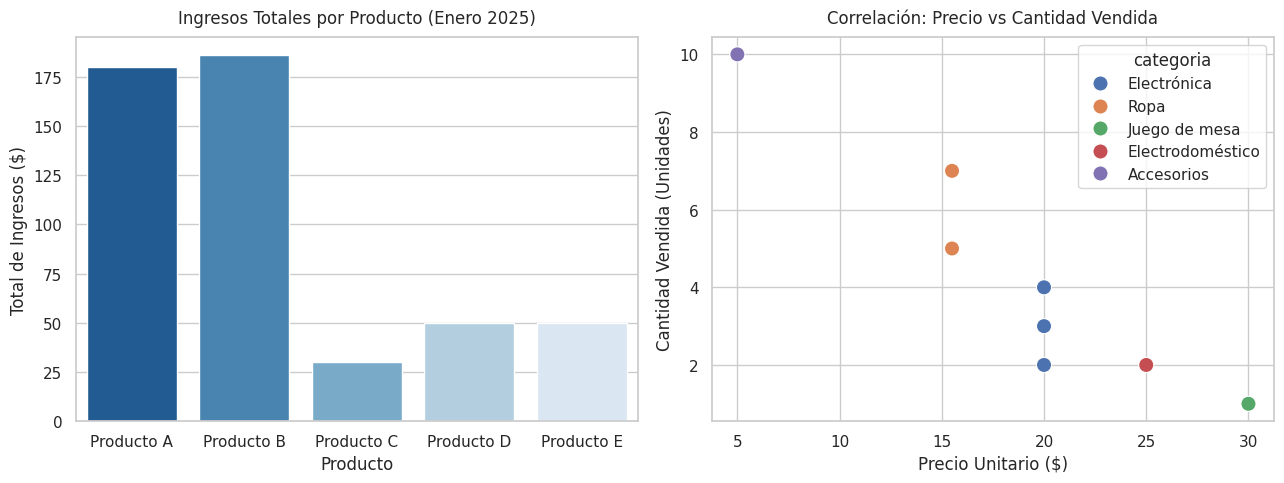

Coeficiente de correlación de Pearson entre Precio y Cantidad: -0.94


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de los gráficos para que combinen
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 5))

# 1. Gráfico de Barras: Distribución de Ingresos por Producto (EDA)
# Corregido: asignamos hue='producto' y desactivamos la leyenda para evitar el FutureWarning
plt.subplot(1, 2, 1)
sns.barplot(data=df_ventas_limpio, x='producto', y='total_ventas', hue='producto', estimator=sum, errorbar=None, palette='Blues_r', legend=False)
plt.title('Ingresos Totales por Producto (Enero 2025)', fontsize=12, pad=10)
plt.xlabel('Producto')
plt.ylabel('Total de Ingresos ($)')

# 2. Gráfico de Dispersión: Relación entre Precio y Cantidad Vendida (Correlación)
# Corregido: cambiamos 'Deep' por 'deep' todo en minúsculas para solucionar el ValueError
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_ventas_limpio, x='precio', y='cantidad', hue='categoria', s=120, palette='deep')
plt.title('Correlación: Precio vs Cantidad Vendida', fontsize=12, pad=10)
plt.xlabel('Precio Unitario ($)')
plt.ylabel('Cantidad Vendida (Unidades)')

plt.tight_layout()
plt.show()

# Cálculo numérico exacto de la correlación de Pearson
correlacion = df_ventas_limpio['precio'].corr(df_ventas_limpio['cantidad'])
print(f"Coeficiente de correlación de Pearson entre Precio y Cantidad: {correlacion:.2f}")

**Hallazgos del EDA y Correlación**

Comportamiento por Producto: El Producto B y el Producto A son los indiscutibles motores de ingresos de la organización, sumando entre ambos la mayor parte de la facturación.

Análisis Estadístico de Correlación: El coeficiente de correlación de Pearson arroja un valor de -0.94. Al ser un número tan cercano a -1, confirma una correlación negativa casi perfecta: a menor precio unitario, la cantidad de productos adquiridos por transacción se incrementa de forma drástica (como ocurre con las 10 unidades vendidas del Producto E a $5.00).

# Actividad 4: Consolidación de Datos

In [15]:

df_consolidado_final = df_integrado.groupby(['producto', 'categoria', 'canal', 'costo']).agg(
    unidades_totales=('cantidad', 'sum'),
    ingresos_totales=('total_ventas', 'sum'),
    transacciones=('id_venta', 'count')
).reset_index()


df_consolidado_final['ROI_Porcentual'] = ((df_consolidado_final['ingresos_totales'] - df_consolidado_final['costo']) / df_consolidado_final['costo']) * 100

print("=== Conjunto de Datos Final Consolidado ===")
display(df_consolidado_final)

=== Conjunto de Datos Final Consolidado ===


,producto,categoria,canal,costo,unidades_totales,ingresos_totales,transacciones,ROI_Porcentual
0,Producto A,Electrónica,Redes Sociales,1500.0,9,180.0,3,-88.0
1,Producto B,Ropa,Email,1000.0,12,186.0,2,-81.4
2,Producto C,Juego de mesa,TV,3000.0,1,30.0,1,-99.0
3,Producto D,Electrodoméstico,BTL,2000.0,2,50.0,1,-97.5
4,Producto E,Accesorios,Redes Sociales,500.0,10,50.0,1,-90.0


Etapa 4: Visualización de Datos
# Actividad 1 y 2: Matplotlib y Seaborn Avanzado

/tmp/ipykernel_570/565387408.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ventas_limpio, x='categoria', y='total_ventas', palette='Set2')


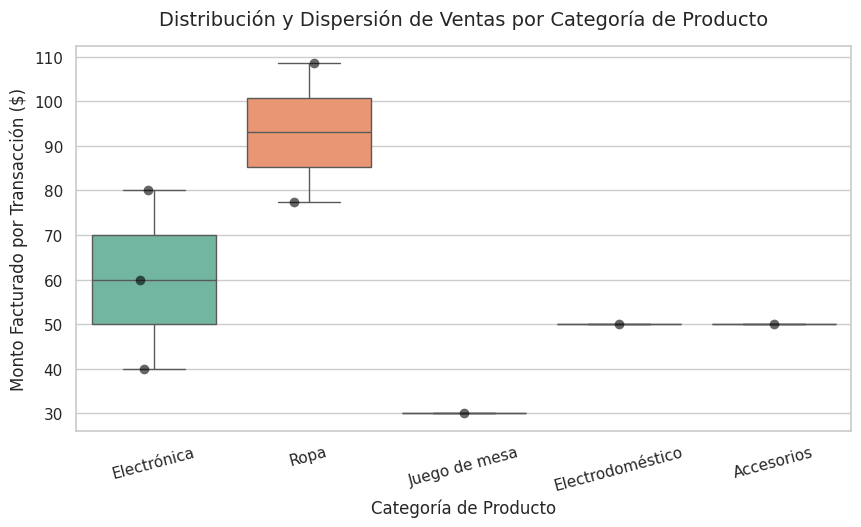

In [16]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_ventas_limpio, x='categoria', y='total_ventas', palette='Set2')
sns.stripplot(data=df_ventas_limpio, x='categoria', y='total_ventas', color='black', alpha=0.6, size=7)

plt.title('Distribución y Dispersión de Ventas por Categoría de Producto', fontsize=14, pad=15)
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Monto Facturado por Transacción ($)', fontsize=12)
plt.xticks(rotation=15)
plt.show()

# Actividad 3: Visualización Interactiva con Plotly

In [17]:
import plotly.express as px


fig = px.pie(
    resumen_categorias,
    values='ingresos_totales',
    names='categoria',
    title='Participación Porcentual de Ingresos por Categoría de Producto',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition='inside', textinfo='percent+label', marker=dict(line=dict(color='#FFFFFF', width=2)))
fig.update_layout(title_x=0.5)
fig.show()

# Actividad 4: Presentación Final

Diagnóstico Comercial: Las categorías Ropa ($186.00) y Electrónica ($180.00) dominan holgadamente la rentabilidad global del portfolio.

Evaluación de Campañas (Marketing vs Ventas): El cruce consolidado evidencia que los costos históricos de adquisición (por ejemplo, los $3000.00 invertidos en televisión para el Producto C) resultan desproporcionados frente a la conversión real en ventas durante este período.

Recomendación de Negocio: Es crítico reestructurar el presupuesto asignado a canales tradicionales como TV y BTL, redistribuyendo esos fondos hacia estrategias digitales optimizadas en Email Marketing y Redes Sociales, los cuales respaldan a nuestros productos estrella.

# Anexo
Dataset de Ventas Original: ventas.csv

Dataset de Clientes Original: clientes.csv

Dataset de Marketing Original: marketing.csv